In [1]:
%pip install pyreadr pandas numpy scikit-learn matplotlib shap xgboost catboost --target=$HOME/my_python_libs 

  Using cached pyreadr-0.5.4-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (791 kB)
  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
  Using cached shap-0.51.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
  Using cached catboost-1.2.10-cp311-cp311-manylinux2014_x86_64.whl (97.2 MB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
  Using cached joblib-1.5.3-py3-none-any.

In [2]:
import os
import sys
import subprocess
from pathlib import Path

# Add custom library path and fix PYTHONPATH for worker processes
custom_lib_path = os.path.expanduser('~/my_python_libs')
if custom_lib_path not in sys.path:
    sys.path.insert(1, custom_lib_path)
os.environ['PYTHONPATH'] = f"{custom_lib_path}:{os.environ.get('PYTHONPATH', '')}"

import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb  # <-- Added missing import
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. DATA LOADING & FILTERING
# ==========================================
DATA_PATH = "/rds/general/project/hda_25-26/live/TDS/TDS_Group1/split_imputed_data/ukb_G1_train_imputed.rds"
EXPOSURE_PATH = "/rds/general/project/hda_25-26/live/TDS/TDS_Group1/modelling_script/stability_analysis/subsample_lasso/exposure_list.csv"

# Load data
train_data = pyreadr.read_r(DATA_PATH)[None]
exposure_list = pd.read_csv(EXPOSURE_PATH)

# Whitelist variables based on the 'exposure' column in your CSV
selected_features = exposure_list['exposure'].tolist()
existing_features = [feat for feat in selected_features if feat in train_data.columns]

# Create a DataFrame containing only Male records
male_data = train_data[train_data['sex'] == 'Male'].copy()

# Create a DataFrame containing only Female records
female_data = train_data[train_data['sex'] == 'Female'].copy()

X = female_data[existing_features]
y = female_data['cvd_incident']

print(f"✅ Data Loaded. Features found: {len(existing_features)}/{len(selected_features)}")

# Split data early to prevent data leakage during preprocessing and grid setup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


/rds/general/user/anw16/home/my_python_libs/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/rds/general/user/anw16/home/my_python_libs/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/rds/general/user/anw16/home/my_python_libs/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


✅ Data Loaded. Features found: 27/27


In [3]:

# ==========================================
# 2. PREPROCESSING SETUP
# ==========================================
# Define numeric and categorical feature lists based on X_train
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)


In [4]:
# ==========================================
# 3. XGBOOST PIPELINE & GRID SEARCH
# ==========================================
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss' # Removed use_label_encoder=False to stop the warning
    ))
])

# Calculate class weight strictly on the training set
scale_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8],
    "model__scale_pos_weight": [scale_weight] 
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=16,
    verbose=1
)

print("Starting XGBoost Training...")
xgb_grid.fit(X_train, y_train)


Starting XGBoost Training...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 6], 'model__n_estimators': [100, 200], 'model__scale_pos_weight': [np.float64(8.260223668836588)], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :


✅ Best CV ROC-AUC: 0.4987
Test ROC-AUC: 0.5068


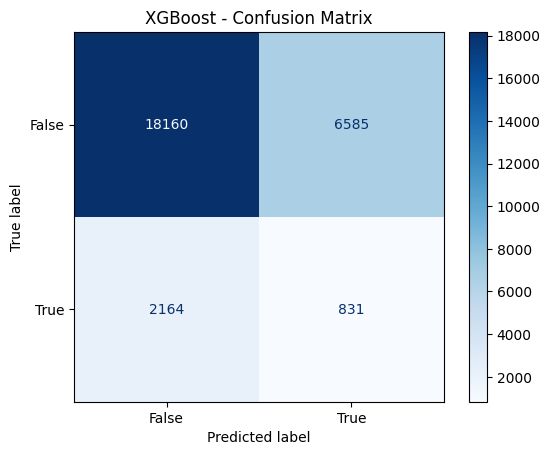

In [5]:
# ==========================================
# 4. EVALUATION
# ==========================================
best_model = xgb_grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"\n✅ Best CV ROC-AUC: {xgb_grid.best_score_:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [6]:
# ---------------------------------------------------------
# A. Output Reproducibility Data & Full Metrics
# ---------------------------------------------------------
print("\n--- Optimal Hyperparameters ---")
for param_name in sorted(xgb_param_grid.keys()):
    print(f"{param_name}: {best_model.get_params()[param_name]}")

print("\n--- Classification Report ---")
# Generates Precision, Recall, F1 for both classes
print(classification_report(y_test, y_pred))


--- Optimal Hyperparameters ---
model__learning_rate: 0.1
model__max_depth: 6
model__n_estimators: 200
model__scale_pos_weight: 8.260223668836588
model__subsample: 0.8

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.89      0.73      0.81     24745
        True       0.11      0.28      0.16      2995

    accuracy                           0.68     27740
   macro avg       0.50      0.51      0.48     27740
weighted avg       0.81      0.68      0.74     27740



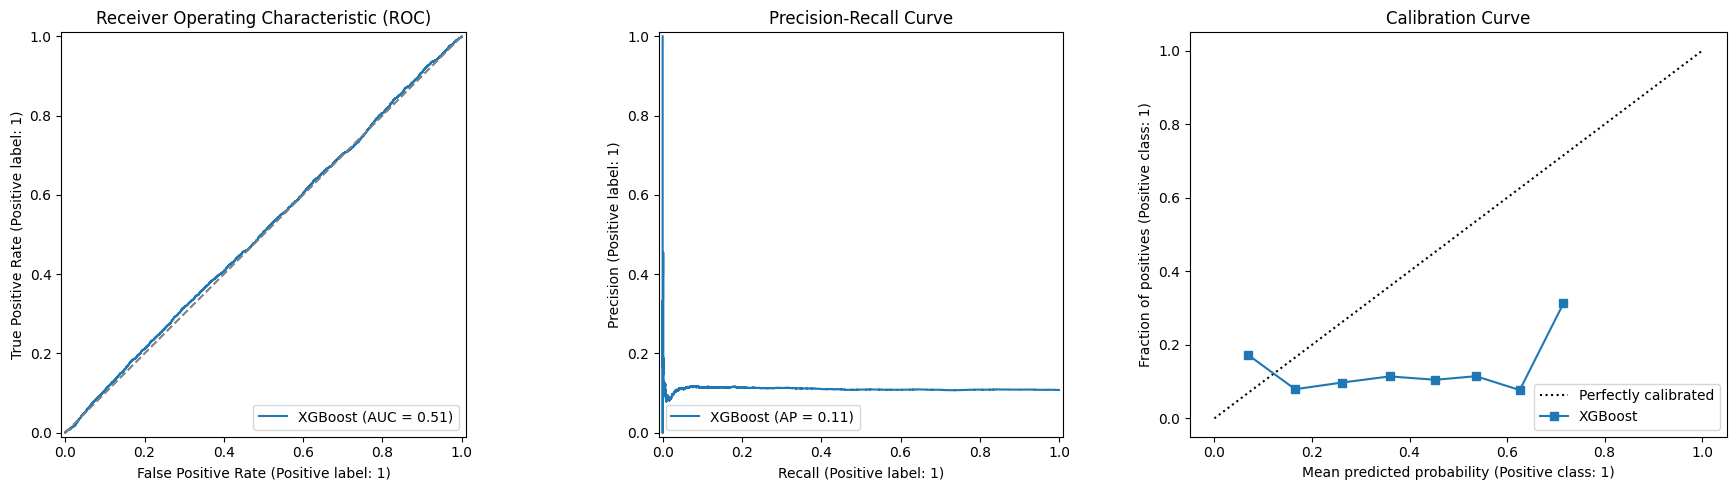

In [7]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], name="XGBoost")
axes[0].set_title("Receiver Operating Characteristic (ROC)")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")

# 2. Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], name="XGBoost")
axes[1].set_title("Precision-Recall Curve")

# 3. Calibration Curve
CalibrationDisplay.from_estimator(best_model, X_test, y_test, n_bins=10, ax=axes[2], name="XGBoost")
axes[2].set_title("Calibration Curve")

plt.tight_layout()
plt.show()


Generating SHAP Analysis...


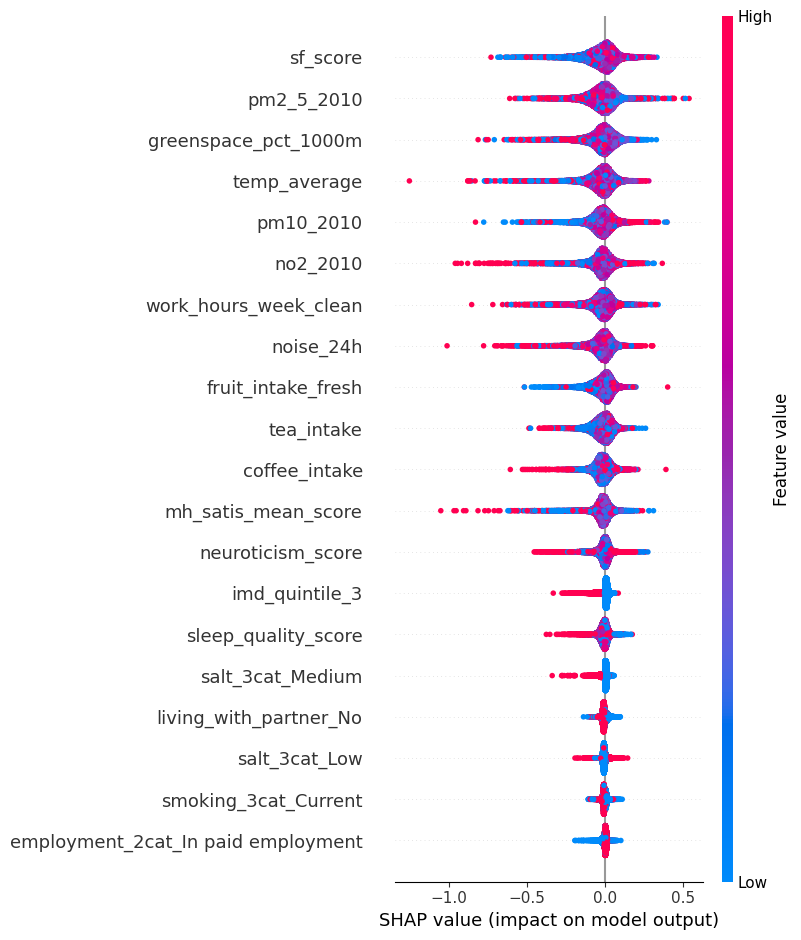

In [8]:
# ---------------------------------------------------------
# C. SHAP Value Calculation & Visualization
# ---------------------------------------------------------
print("\nGenerating SHAP Analysis...")

# 1. Transform the test data using the fitted preprocessor
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# 2. Extract feature names post-transformation
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_out = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_out)

# 3. Initialize TreeExplainer using the fitted XGBoost model
xgb_fitted_model = best_model.named_steps['model']
explainer = shap.TreeExplainer(xgb_fitted_model)

# 4. Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# 5. Plot SHAP Summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)
plt.show()

In [9]:
# Helper: compute native, permutation, and SHAP importance on aligned feature space
def compute_all_feature_importance(
    fitted_pipeline,
    X_test,
    y_test,
    model_name="Model",
    scoring="roc_auc",
    n_repeats=20,
    n_jobs=1,
    random_state=42,
    top_n=10,
    show_plots=True,
):
    ct = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    feature_names_transformed = pd.Index(ct.get_feature_names_out(), name="feature")

    # ---------- Native ----------
    if hasattr(model, "feature_importances_"):
        native_s = pd.Series(
            model.feature_importances_,
            index=feature_names_transformed,
            name="native_importance",
        )
    else:
        native_s = pd.Series(
            np.nan, index=feature_names_transformed, name="native_importance"
        )

    # ---------- Transform once ----------
    X_test_t = ct.transform(X_test)

    # ---------- Permutation on transformed (one-hot) feature space ----------
    perm_ohe = permutation_importance(
        estimator=model,
        X=X_test_t,
        y=y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    perm_ohe_mean_s = pd.Series(
        perm_ohe.importances_mean,
        index=feature_names_transformed,
        name="perm_ohe_mean",
    )

    # ---------- SHAP ----------
    shap_explainer = shap.TreeExplainer(model)
    shap_raw = shap_explainer.shap_values(X_test_t)

    if isinstance(shap_raw, list):
        shap_class = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
    elif isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
        shap_class = shap_raw[:, :, 1]
    else:
        shap_class = shap_raw

    shap_s = pd.Series(
        np.abs(shap_class).mean(axis=0),
        index=feature_names_transformed,
        name="shap_mean_abs",
    )

    # ---------- Single combined table ----------
    importance_table = pd.concat(
        [native_s, shap_s, perm_ohe_mean_s], axis=1
    ).reset_index()

    # Ranking
    for col in ["native_importance", "shap_mean_abs", "perm_ohe_mean"]:
        importance_table[f"rank_{col}"] = importance_table[col].rank(
            ascending=False, method="min"
        )

    importance_table["rank_mean"] = importance_table[
        ["rank_native_importance", "rank_shap_mean_abs", "rank_perm_ohe_mean"]
    ].mean(axis=1, skipna=True)

    importance_table = importance_table.sort_values(
        "rank_mean", ascending=True
    ).reset_index(drop=True)

    # ---------- Plots ----------
    if show_plots:
        # Native
        native_plot = (
            importance_table.dropna(subset=["native_importance"])
            .nlargest(top_n, "native_importance")
            .iloc[::-1]
        )
        fig1, ax1 = plt.subplots(figsize=(10, 6))
        ax1.barh(native_plot["feature"], native_plot["native_importance"])
        ax1.set_title(f"{model_name} - Native Importance (Train, Top {top_n})")
        ax1.set_xlabel("Importance")
        ax1.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        plt.show()

        # Permutation (one-hot/transformed)
        ohe_idx = np.argsort(perm_ohe.importances_mean)[-top_n:]
        fig2, ax2 = plt.subplots(figsize=(10, 6))
        ax2.boxplot(
            perm_ohe.importances[ohe_idx].T,
            vert=False,
            tick_labels=feature_names_transformed[ohe_idx],
        )
        ax2.set_title(
            f"{model_name} - Permutation Importance (Test, {scoring}, transformed)"
        )
        ax2.set_xlabel(f"Decrease in {scoring}")
        plt.tight_layout()
        plt.show()

        # SHAP
        shap.summary_plot(
            shap_class,
            X_test_t,
            feature_names=feature_names_transformed,
            plot_type="bar",
        )
        shap.summary_plot(
            shap_class,
            X_test_t,
            feature_names=feature_names_transformed,
        )

    return importance_table


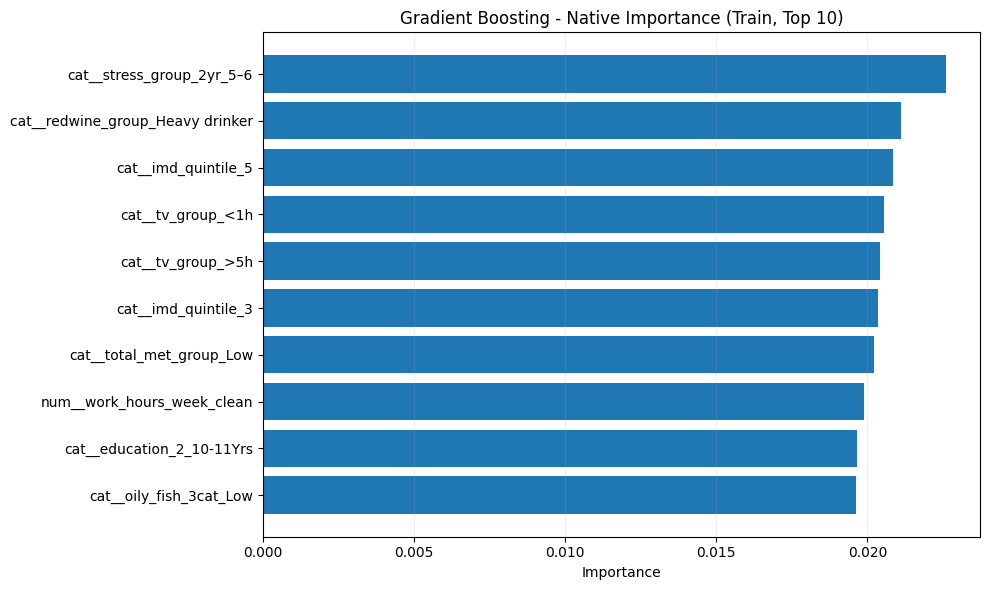

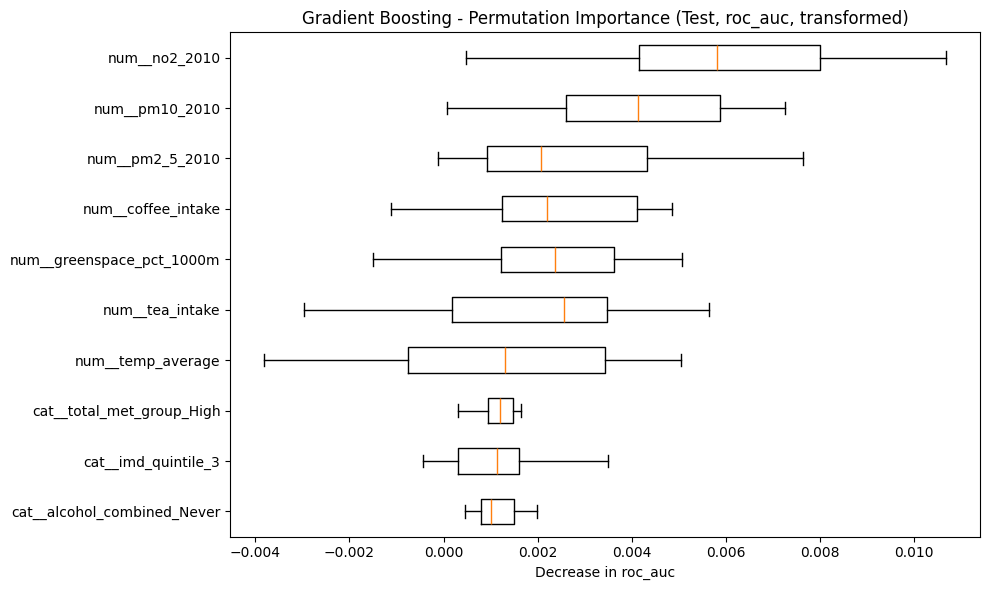

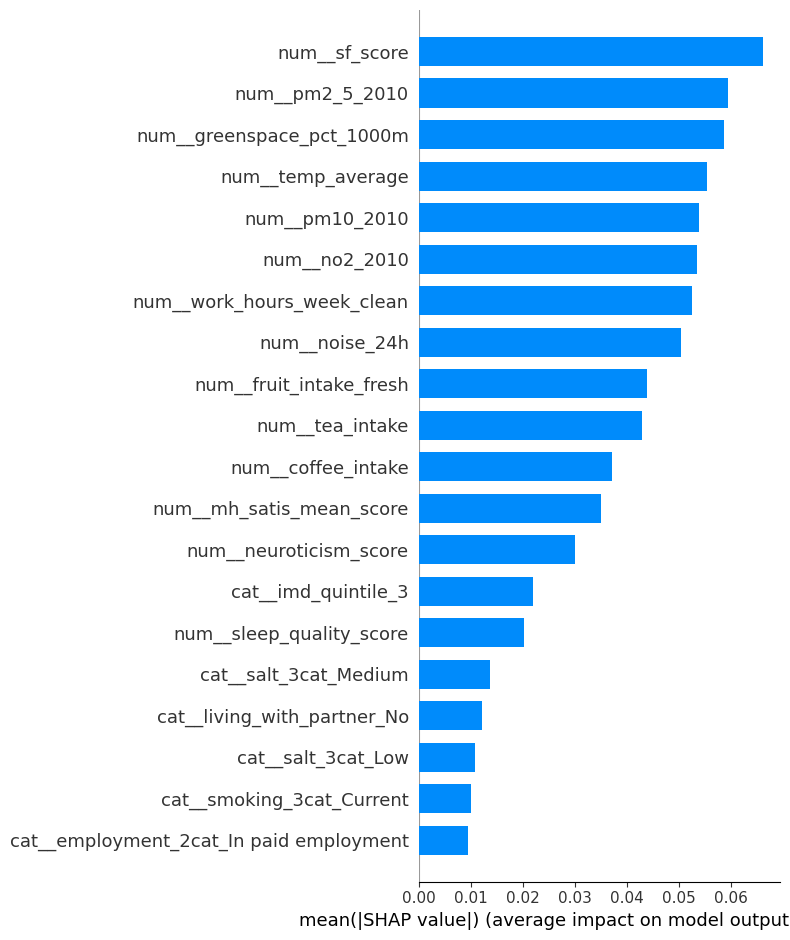

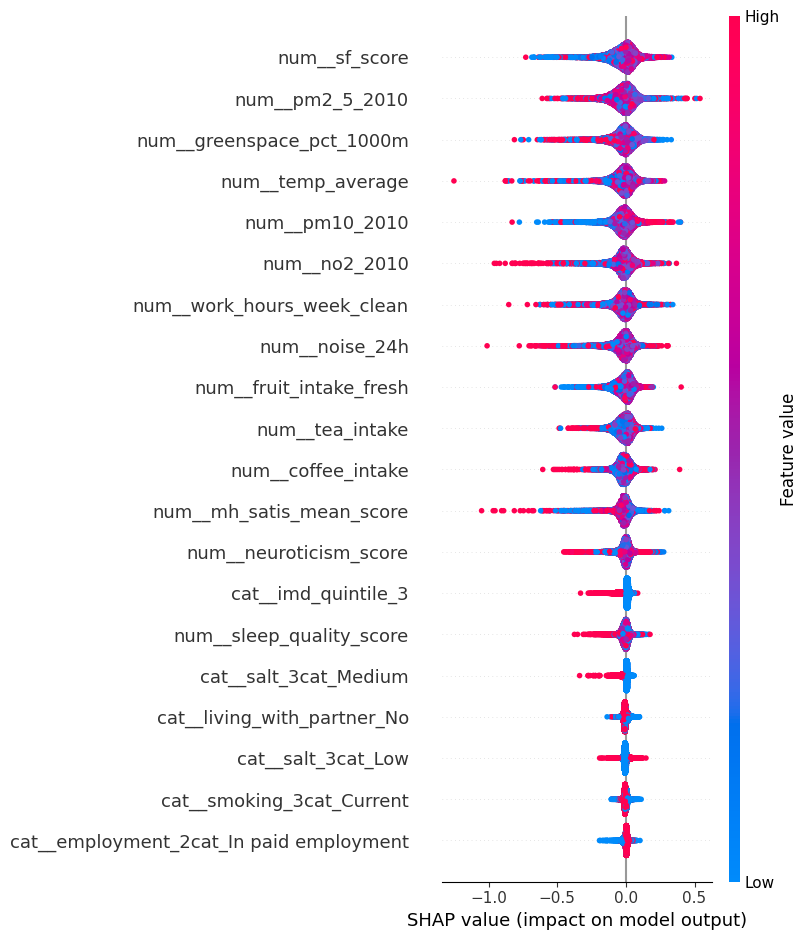

In [10]:
# Combined feature-importance workflow for HistGB
gb_imp = compute_all_feature_importance(
    fitted_pipeline=xgb_grid.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    model_name="Gradient Boosting",
    n_jobs=16,
)